In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
# Plot Settings
sns.set_style('darkgrid')
matplotlib.rcParams['figure.figsize'] = (10, 6)
matplotlib.rcParams['font.size'] = 14

In [3]:
# 1. Load Dataset
df = pd.read_csv('/content/sample_data/Housing.csv')

print("Shape:", df.shape)
print("\nFirst 5 Rows:")
print(df.head())

print("\nDataset Info:")
df.info()

print("\nDescriptive Statistics:")
print(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())

Shape: (21613, 21)

First 5 Rows:
           id             date     price  bedrooms  bathrooms  sqft_living  \
0  7229300521  20141013T000000  231300.0         2       1.00         1180   
1  6414100192  20141209T000000  538000.0         3       2.25         2570   
2  5631500400  20150225T000000  180000.0         2       1.00          770   
3  2487200875  20141209T000000  604000.0         4       3.00         1960   
4  1954400510  20150218T000000  510000.0         3       2.00         1680   

   sqft_lot  floors  waterfront  view  ...  grade  sqft_above  sqft_basement  \
0      5650     1.0           0     0  ...      7        1180              0   
1      7242     2.0           0     0  ...      7        2170            400   
2     10000     1.0           0     0  ...      6         770              0   
3      5000     1.0           0     0  ...      7        1050            910   
4      8080     1.0           0     0  ...      8        1680              0   

   yr_built  yr_

In [4]:
# 2. Data Cleaning & Encoding
df.dropna(inplace=True)

# Encode categorical columns
le = LabelEncoder()
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

print("\nAfter Encoding — First 5 Rows:")
print(df.head())


After Encoding — First 5 Rows:
           id  date     price  bedrooms  bathrooms  sqft_living  sqft_lot  \
0  7229300521   164  231300.0         2       1.00         1180      5650   
1  6414100192   220  538000.0         3       2.25         2570      7242   
2  5631500400   290  180000.0         2       1.00          770     10000   
3  2487200875   220  604000.0         4       3.00         1960      5000   
4  1954400510   283  510000.0         3       2.00         1680      8080   

   floors  waterfront  view  ...  grade  sqft_above  sqft_basement  yr_built  \
0     1.0           0     0  ...      7        1180              0      1955   
1     2.0           0     0  ...      7        2170            400      1951   
2     1.0           0     0  ...      6         770              0      1933   
3     1.0           0     0  ...      7        1050            910      1965   
4     1.0           0     0  ...      8        1680              0      1987   

   yr_renovated  zipcode

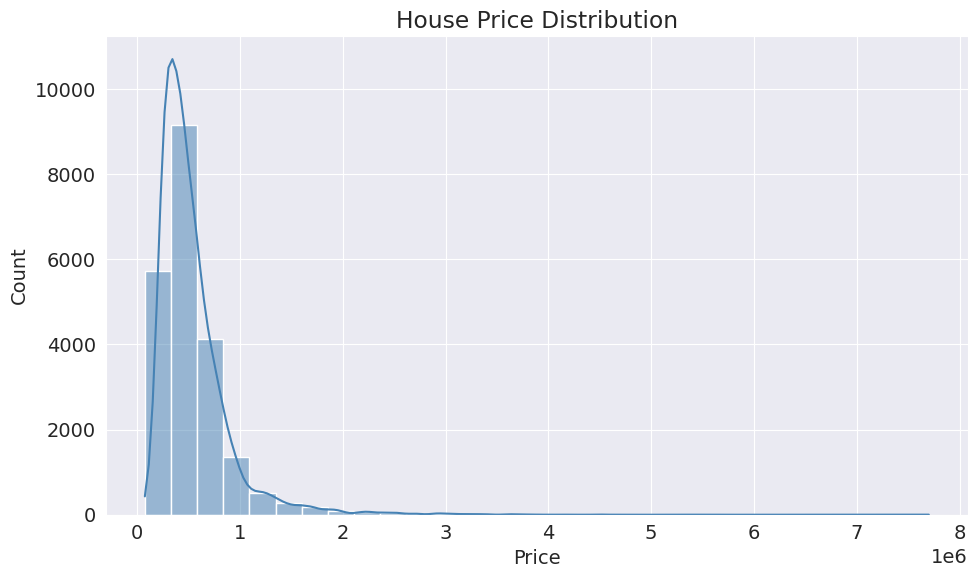

In [5]:
# 3. EDA — Price Distribution

plt.figure()
sns.histplot(df['price'], bins=30, kde=True, color='steelblue')
plt.title('House Price Distribution')
plt.xlabel('Price')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

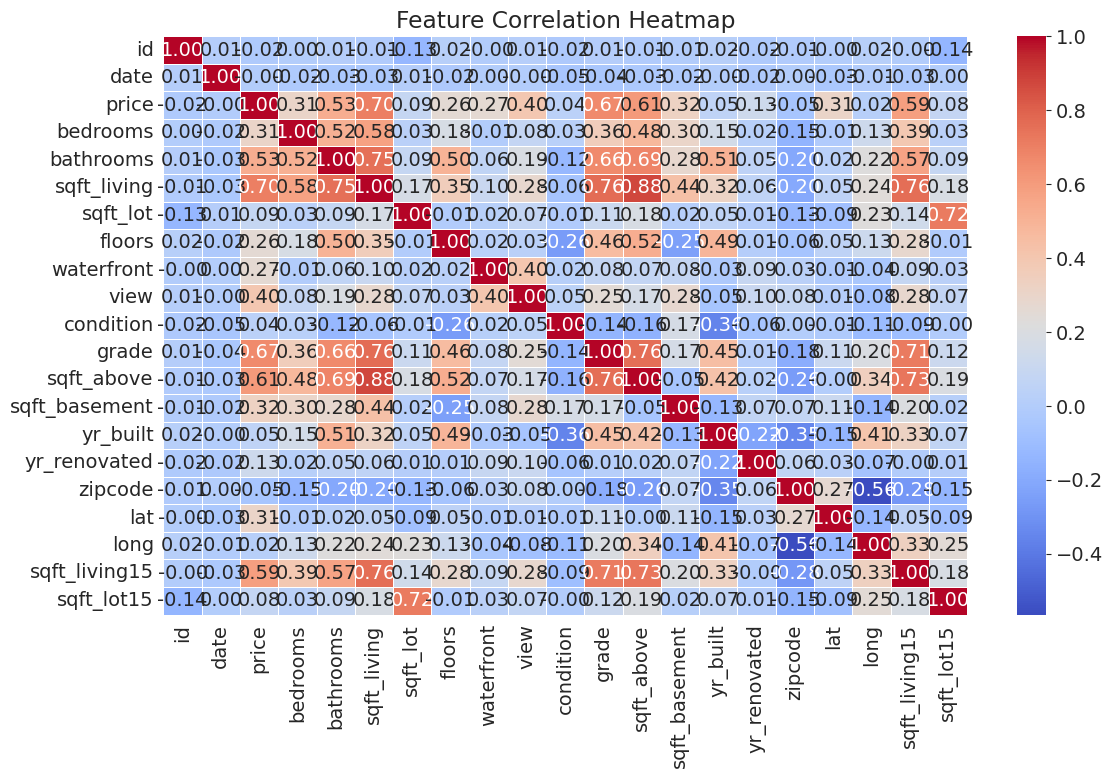

In [6]:
# 4. EDA — Correlation Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

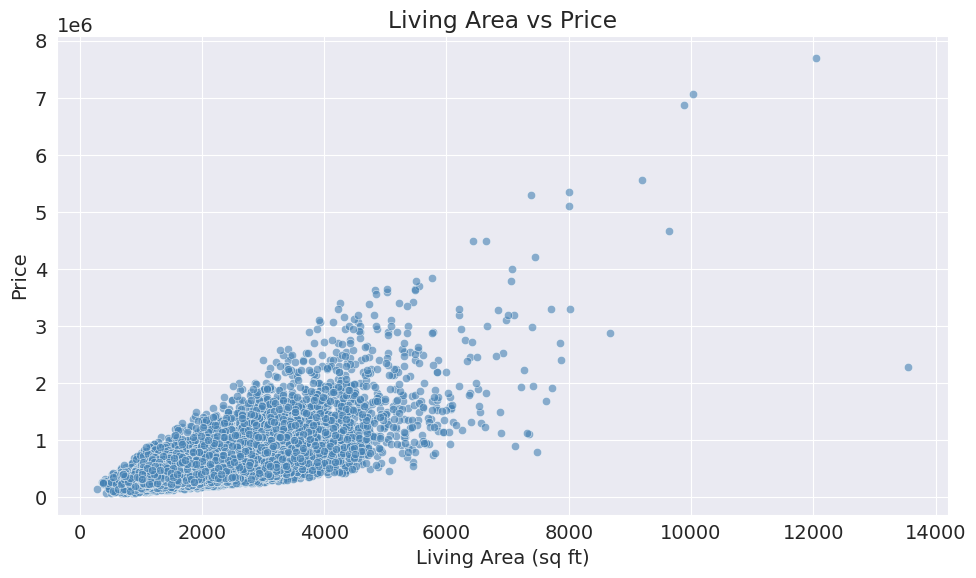

In [11]:
plt.figure()
sns.scatterplot(data=df, x='sqft_living', y='price', color='steelblue', alpha=0.6)
plt.title('Living Area vs Price')
plt.xlabel('Living Area (sq ft)')
plt.ylabel('Price')
plt.tight_layout()
plt.show()

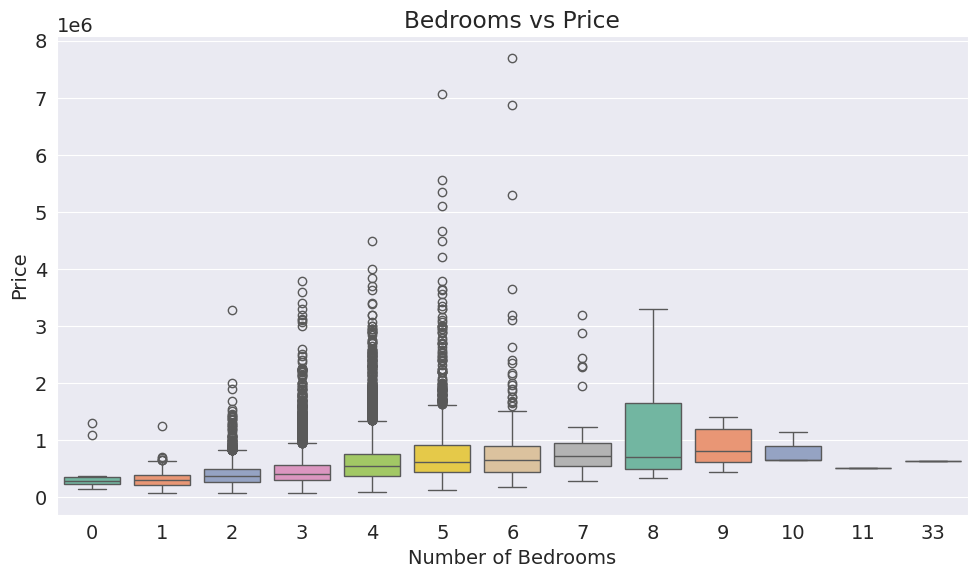

In [12]:
# 6. EDA — Bedrooms vs Price

plt.figure()
sns.boxplot(data=df, x='bedrooms', y='price', hue='bedrooms',
            palette='Set2', legend=False)
plt.title('Bedrooms vs Price')
plt.xlabel('Number of Bedrooms')
plt.ylabel('Price')
plt.tight_layout()
plt.show()


In [13]:
# 7. Feature & Target Split
X = df.drop('price', axis=1)
y = df['price']

# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(f"\nTraining samples: {len(X_train)}, Testing samples: {len(X_test)}")


Training samples: 17290, Testing samples: 4323


In [14]:
# 8. Train Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

lr_mae = mean_absolute_error(y_test, lr_preds)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))

print(f"\nLinear Regression:")
print(f"  MAE  : {lr_mae:,.2f}")
print(f"  RMSE : {lr_rmse:,.2f}")


Linear Regression:
  MAE  : 127,168.33
  RMSE : 212,104.39


In [15]:
# 9. Train Gradient Boosting

gb_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_model.fit(X_train, y_train)
gb_preds = gb_model.predict(X_test)

gb_mae = mean_absolute_error(y_test, gb_preds)
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_preds))

print(f"\nGradient Boosting:")
print(f"  MAE  : {gb_mae:,.2f}")
print(f"  RMSE : {gb_rmse:,.2f}")


Gradient Boosting:
  MAE  : 80,460.51
  RMSE : 146,583.58


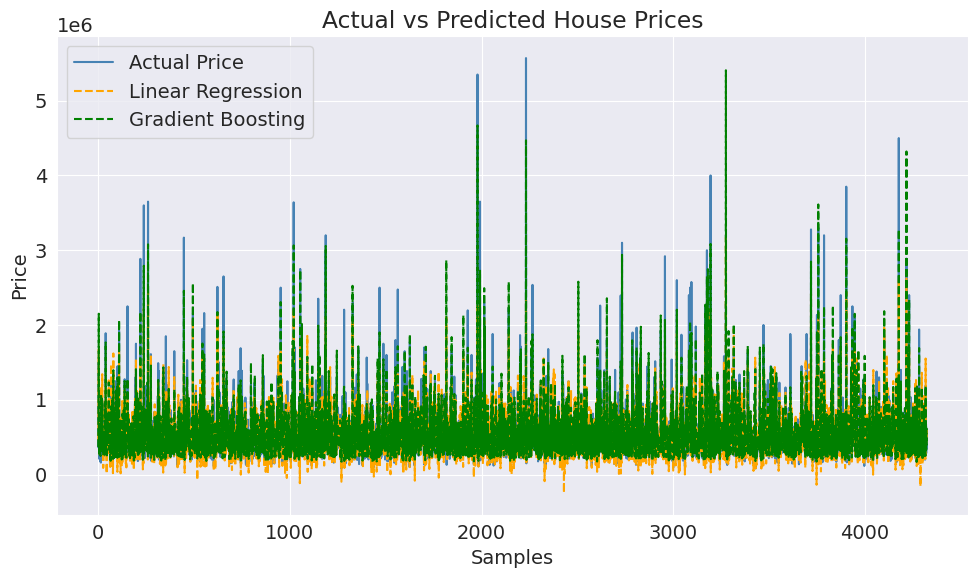

In [16]:
# 10. Plot Actual vs Predicted — Both Models
plt.figure()
plt.plot(y_test.values, label='Actual Price', color='steelblue')
plt.plot(lr_preds, label='Linear Regression', color='orange', linestyle='--')
plt.plot(gb_preds, label='Gradient Boosting', color='green', linestyle='--')
plt.title('Actual vs Predicted House Prices')
plt.xlabel('Samples')
plt.ylabel('Price')
plt.legend()
plt.tight_layout()
plt.show()

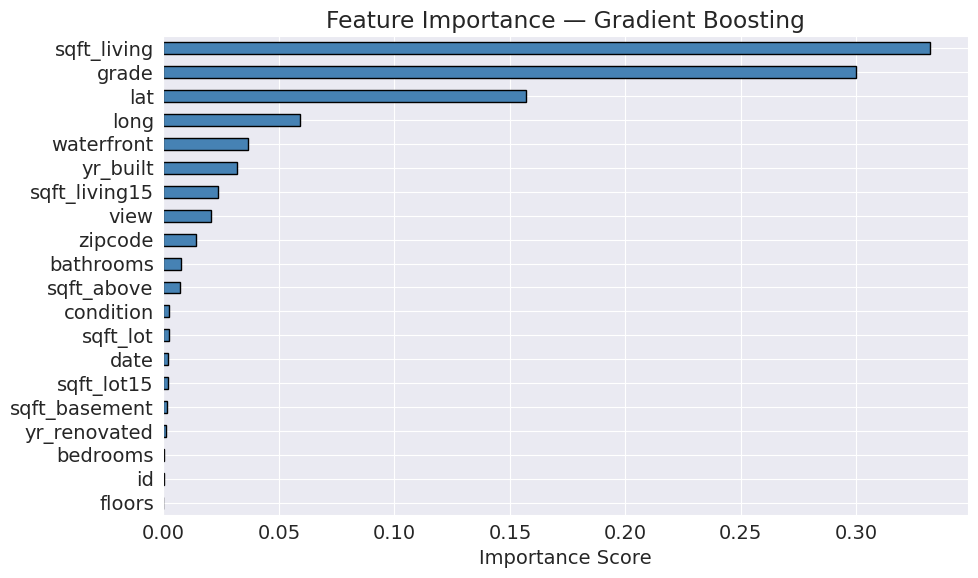

In [17]:
# 11. Feature Importance — Gradient Boosting
plt.figure()
importance = pd.Series(gb_model.feature_importances_, index=X.columns)
importance.sort_values().plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Feature Importance — Gradient Boosting')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()